Ref `link` for complete details.

The purpose of this collab is to assign dynamic coupling-inspired edge weights to a protein to build the protein structure network. It takes in a .gro and a corresponding .xtc file and assigns the edge weight between these two residues as the mean of distances between them / variance of distances between them. The output is a coupling matrix in a .csv format that can then be used for downstream analysis.

In [1]:
!pip install MDAnalysis nglview tqdm --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.2/26.2 MB 30.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 110.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import MDAnalysis as mda
from MDAnalysis.analysis import rms, distances

print("Libraries loaded successfully.")

Libraries loaded successfully.


Upload your .gro and .xtc files

In [13]:
from google.colab import files

uploaded = files.upload()

print("\n Uploaded files:")
for fname in uploaded.keys():
    print(f" - {fname}")

Saving Villin_450K_1ns_noPBC.xtc to Villin_450K_1ns_noPBC.xtc
Saving Villin.gro to Villin.gro

 Uploaded files:
 - Villin_450K_1ns_noPBC.xtc
 - Villin.gro


Enter the protein name

In [14]:
pname = input("Enter protein name (without extension): ").strip()

gro_file = f"{pname}.gro"
xtc_file = f"{pname}_450K_1ns_noPBC.xtc"

print(f"\nUsing files:")
print(f"Structure: {gro_file}")
print(f"Trajectory: {xtc_file}")

Enter protein name (without extension): Villin

Using files:
Structure: Villin.gro
Trajectory: Villin_450K_1ns_noPBC.xtc


In [15]:
print("\nLoading trajectory...")

u = mda.Universe(gro_file, xtc_file)
protein = u.select_atoms("protein and name CA")
n_residues = len(protein)
n_frames = len(u.trajectory)

print(f"Loaded successfully!")
print(f"Number of residues (C-alpha): {n_residues}")
print(f"Number of frames: {n_frames}")


Loading trajectory...
Loaded successfully!
Number of residues (C-alpha): 35
Number of frames: 101


Visualize RMSD


Calculating RMSD...
RMSD calculation complete.


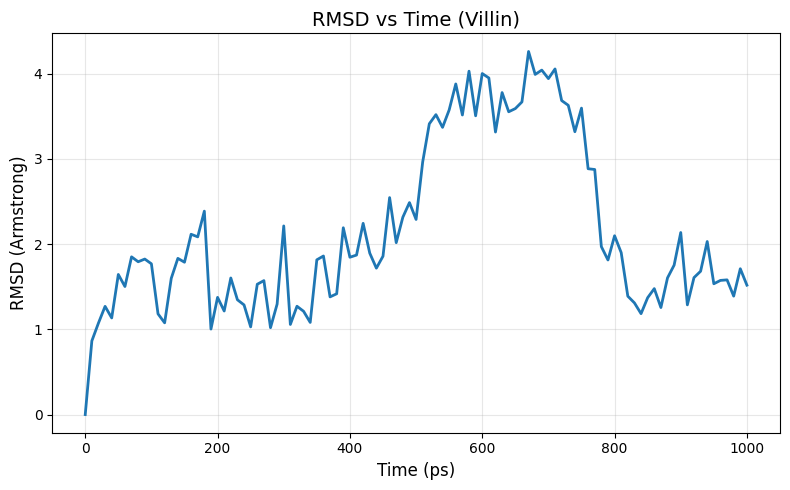

RMSD plot generated.


In [16]:
print("\nCalculating RMSD...")
R = rms.RMSD(protein, protein, ref_frame=0)
R.run()
rmsd = R.results.rmsd[:, 2]  # RMSD column
time = R.results.rmsd[:, 1]  # time column
print("RMSD calculation complete.")

plt.figure(figsize=(8,5))
plt.plot(time, rmsd, linewidth=2)
plt.xlabel("Time (ps)", fontsize=12)
plt.ylabel("RMSD (Armstrong)", fontsize=12)
plt.title(f"RMSD vs Time ({pname})", fontsize=14)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("RMSD plot generated.")

Creating coupling matrix

In [17]:
print("\nComputing pairwise distances across trajectory...")

distance_series = np.zeros((n_frames, n_residues, n_residues))
for frame_idx, ts in enumerate(tqdm(u.trajectory)):
    coords = protein.positions
    dist_matrix = distances.distance_array(coords, coords)
    distance_series[frame_idx] = dist_matrix

print("\nComputing dynamic coupling matrix...")

mean_dist = np.mean(distance_series, axis=0)
var_dist = np.var(distance_series, axis=0)
epsilon = 1e-8
coupling_matrix = mean_dist / (var_dist + epsilon)

output_file = f"{pname}_dynamic_coupling.csv"

pd.DataFrame(coupling_matrix).to_csv(output_file, index=False, header=False)
print(f"\nSaved coupling matrix as: {output_file}")


Computing pairwise distances across trajectory...


100%|██████████| 101/101 [00:00<00:00, 1029.03it/s]


Computing dynamic coupling matrix...

Saved coupling matrix as: Villin_dynamic_coupling.csv


Quick visualization

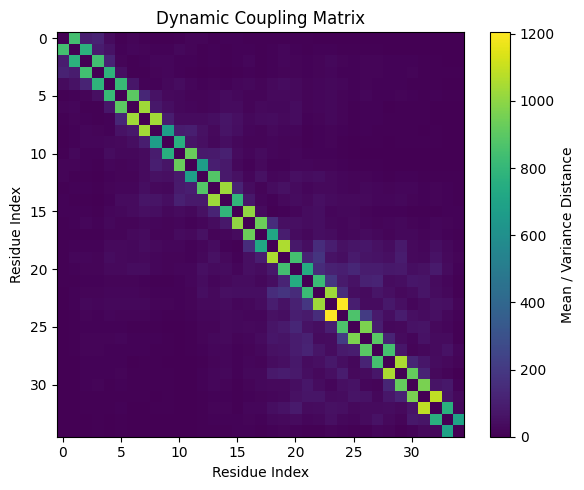

In [18]:
plt.figure(figsize=(6,5))
plt.imshow(coupling_matrix, cmap='viridis', aspect='auto')

plt.colorbar(label="Mean / Variance Distance")
plt.title("Dynamic Coupling Matrix")
plt.xlabel("Residue Index")
plt.ylabel("Residue Index")

plt.tight_layout()
plt.show()